In [1]:
import sys
import ast
import copy
import random
import yaml
import pandas as pd
import os
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.utils.GraphGradCAM import *

p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GCNEmbeddingNet
from src.models.gnn import GINEEmbeddingNet

## Caricamento modelli

In [3]:
# ============================================================
# Caricamento GCN
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)

gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")

GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [4]:
# ============================================================
# Caricamento GINE
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)

gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")

GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


## Dataset di validazione

In [5]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset, get_graph_dataloader, build_node_vocab, build_rel_vocab

In [6]:
import pandas as pd
import os
import torch

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

# ------------------------------------------------------------------
# LABEL MAPPING (FIX: sorted for stability)
# ------------------------------------------------------------------
all_labels = sorted(df_train["labels"].unique())

label2idx = {label: idx for idx, label in enumerate(all_labels)}
idx2label = {idx: label for label, idx in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

NUM_CLASSES = len(label2idx)


val_dataset_gcn = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab_gcn,
    rel_vocab=rel_vocab_gcn,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)

val_dataset_gine = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab_gine,
    rel_vocab=rel_vocab_gine,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

train_dataset = GQAGraphDataset(
    df=df_train,
    label_col="labels",
    node_vocab=node_vocab_gcn,
    rel_vocab=rel_vocab_gcn,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"]
)

train_loader = get_graph_dataloader(
    train_dataset,
    n_classes=NUM_CLASSES,
    n_samples=4,
)

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")
print(f"Val dataset size: {len(val_dataset_gcn)}")

Val dataset size: 3208


## GraphGrad-CAM — Confronto GCN vs GINE


In [7]:
np.random.seed(40)

sample_indices = np.random.choice(
    len(val_dataset_gcn),
    size=5,
    replace=False
)

# Prototypes per ciascun modello (FONDAMENTALE)
prototypes_gcn = compute_prototypes(gcn_model, train_loader, device)
prototypes_gine = compute_prototypes(gine_model, train_loader, device)

# Grad-CAM
cam_gcn = GraphGradCAM(
    gcn_model,
    gcn_model.convs[-1],
    prototypes_gcn
)

cam_gine = GraphGradCAM(
    gine_model,
    gine_model.convs[-1],
    prototypes_gine
)

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


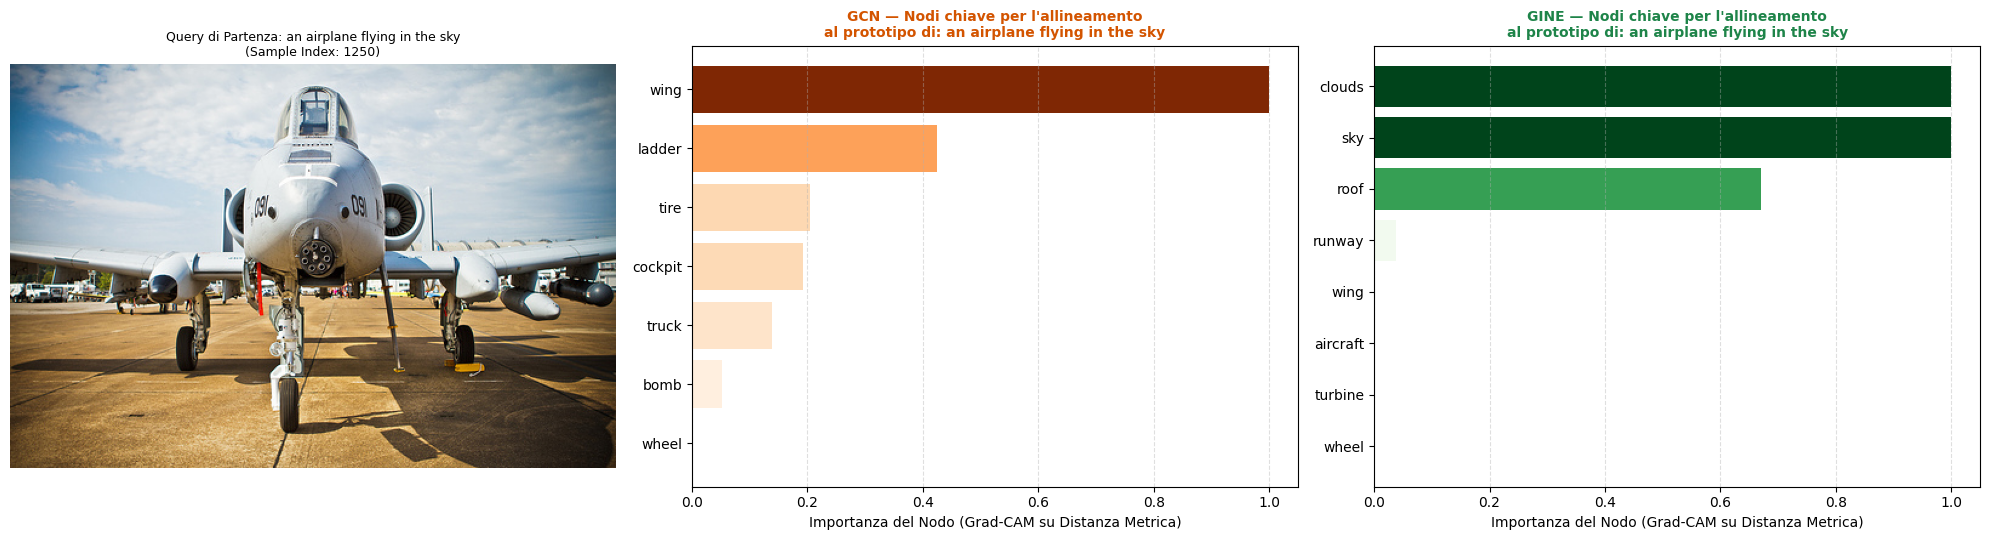

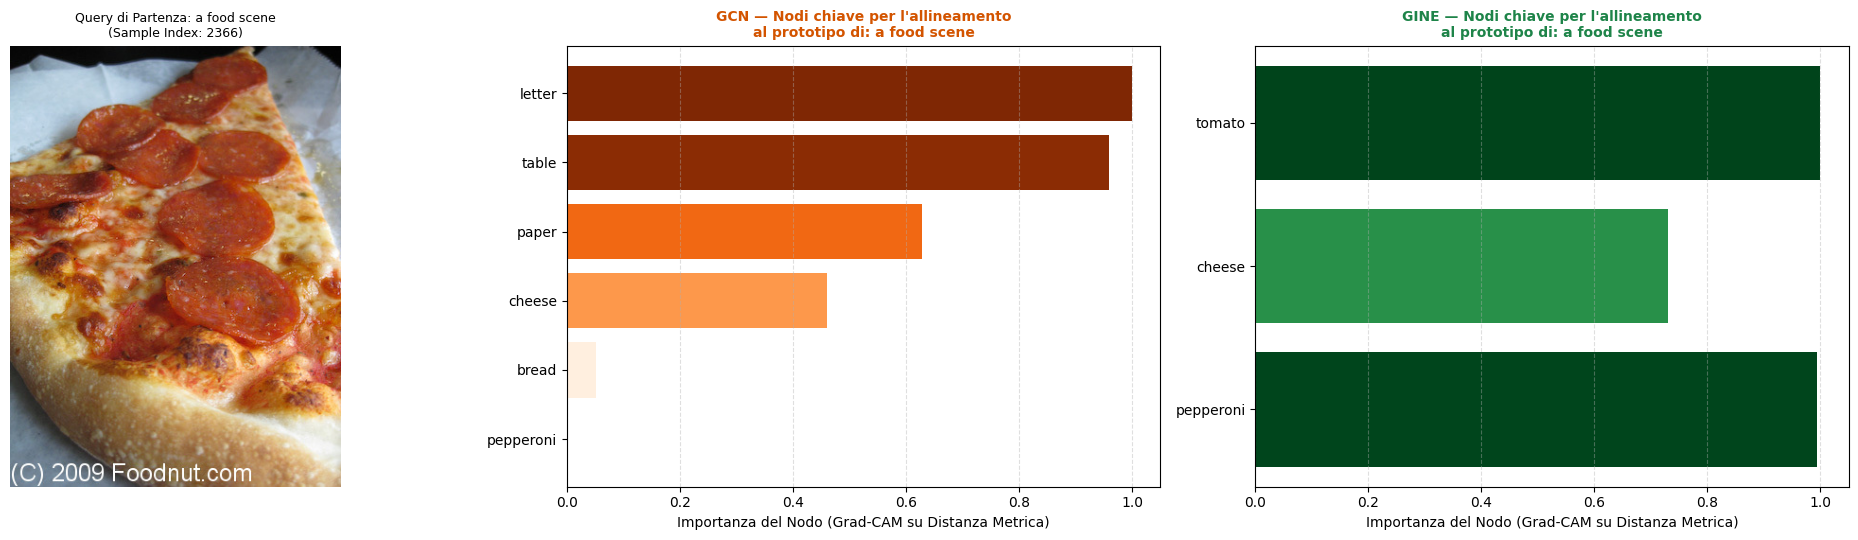

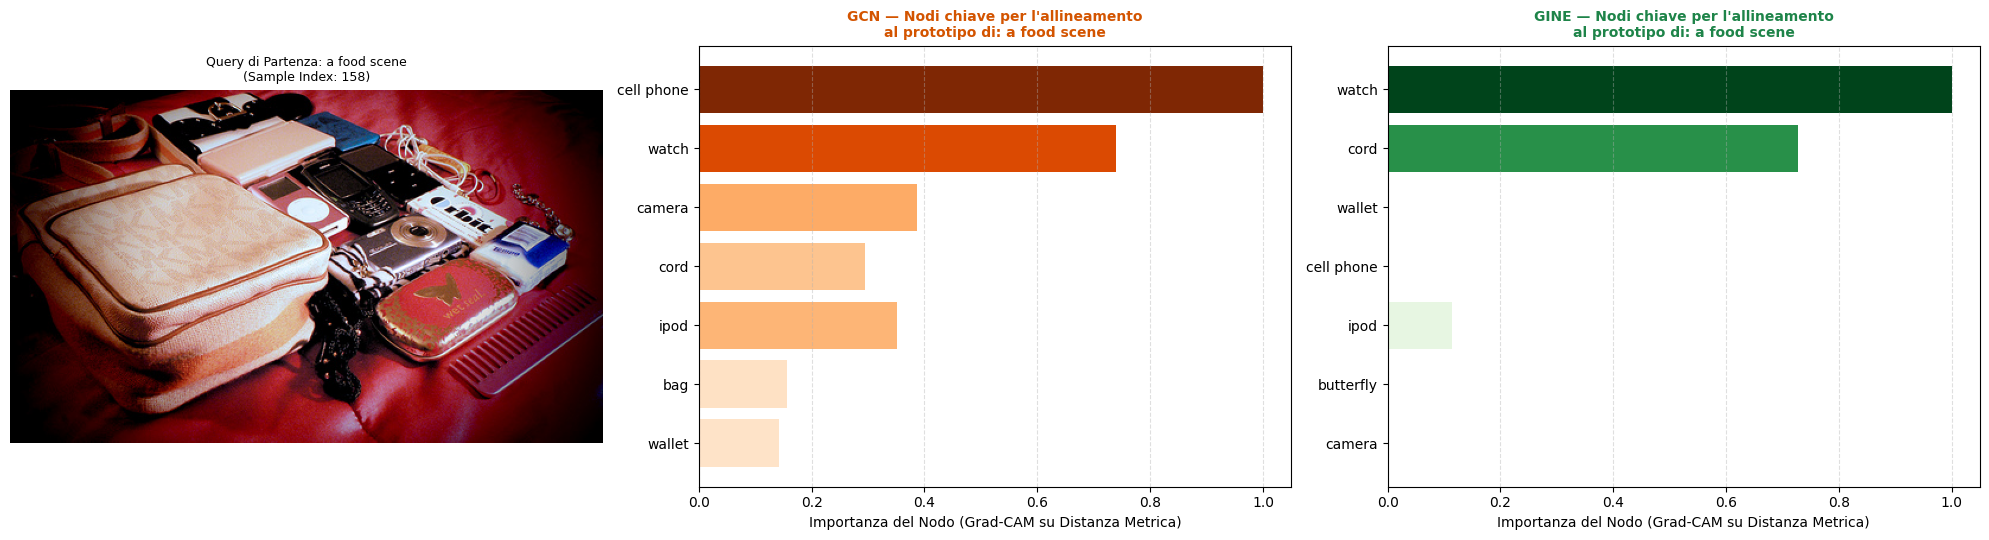

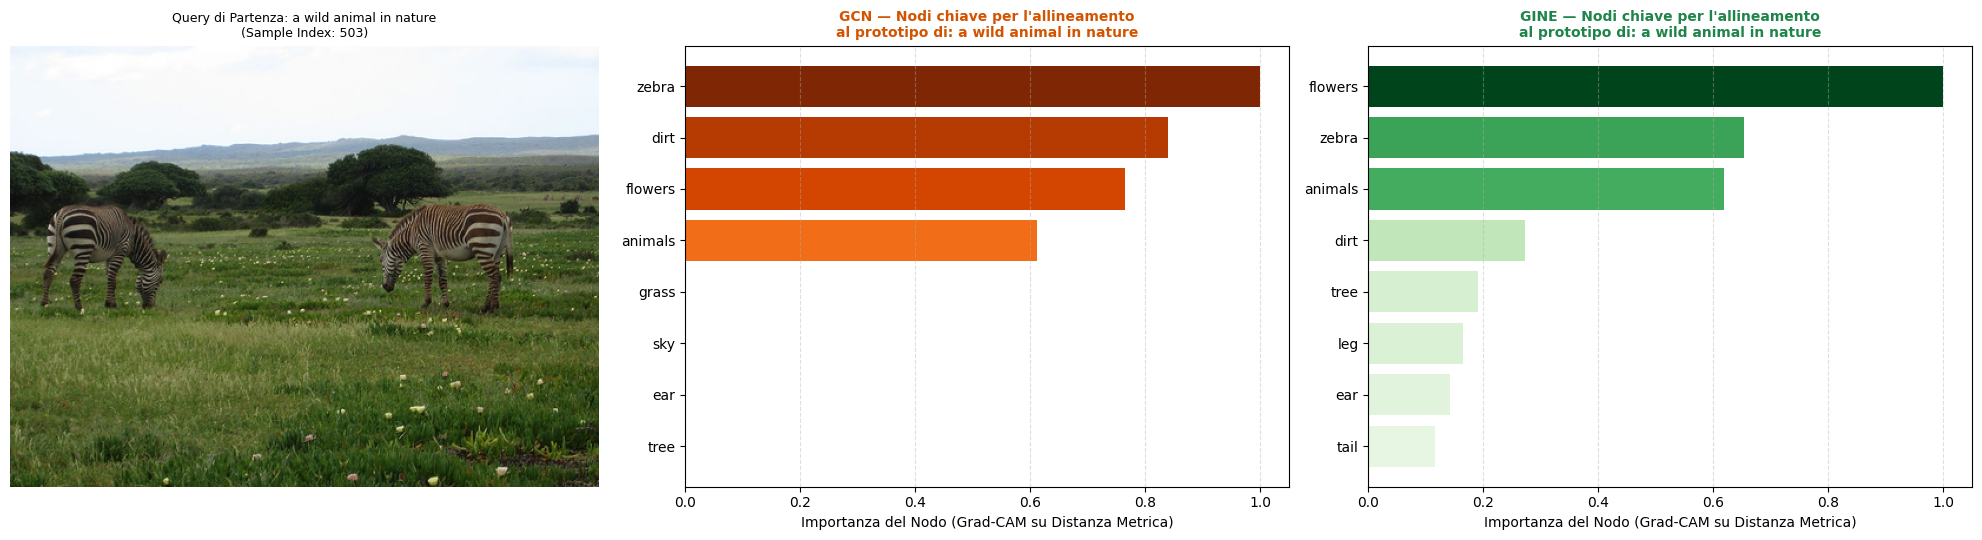

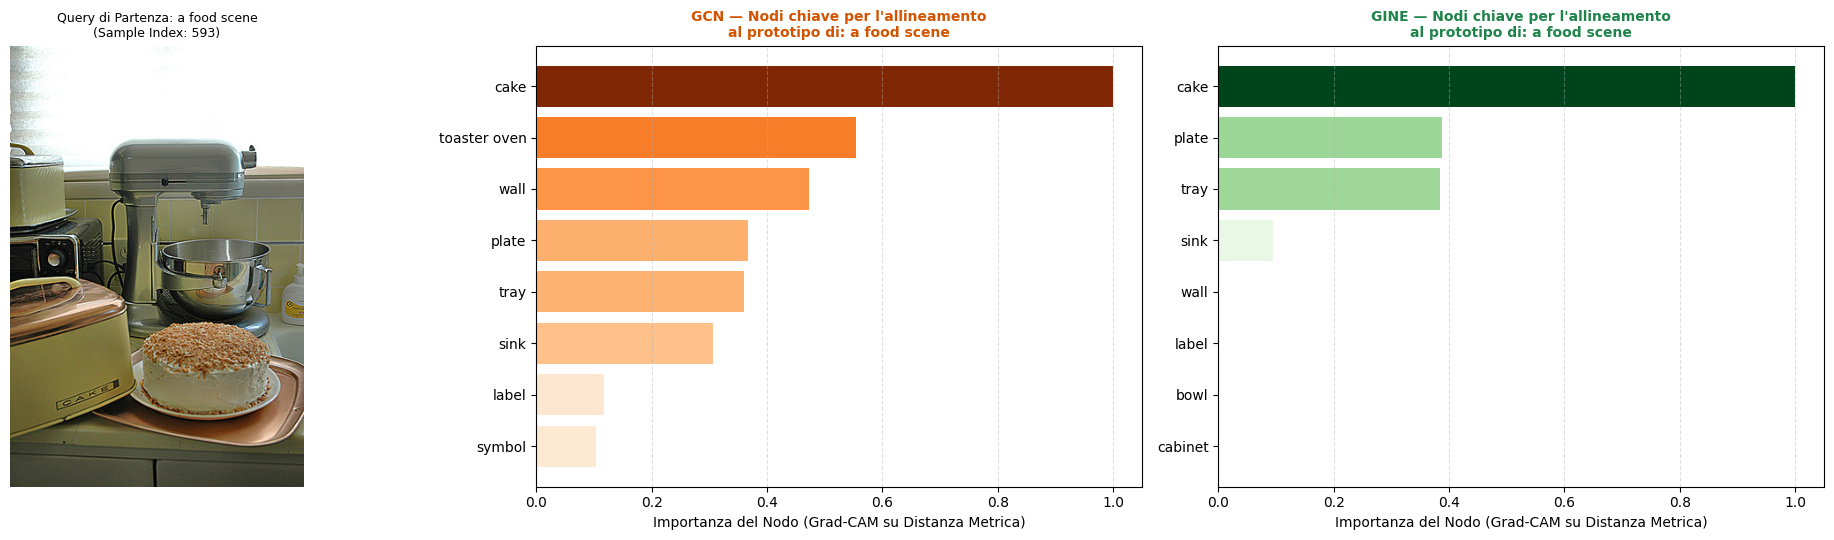

In [8]:

try:
    for idx in sample_indices:
        plot_gradcam_comparison(
            idx=int(idx),
            df_val=df_val,
            image_dir=IMAGE_DIR,
            idx2label=idx2label,
            val_dataset_gcn=val_dataset_gcn,
            val_dataset_gine=val_dataset_gine,
            node_vocab_gcn=node_vocab_gcn,
            node_vocab_gine=node_vocab_gine,
            cam_gcn=cam_gcn,
            cam_gine=cam_gine,
            device=device,
            topk=8
        )
finally:
    cam_gcn.remove_hooks()   # o metodo equivalente
    cam_gine.remove_hooks()


## Studio Globale degli Archi — GINE (GNNExplainer)

#studiarli su specifica classe 

Analisi archi (GINE — GNNExplainer) su 50 campioni...
            Relazione  Importanza Media  Conteggio
0            watching          0.697817          4
1               under          0.563506          2
2          sitting in          0.550312          2
3               using          0.534149          2
4         filled with          0.532373          2
5              around          0.523641          4
6         standing on          0.412545          4
7                near          0.378004         44
8              behind          0.371533         14
9             holding          0.365430         10
10                 on          0.347159         92
11               with          0.322182         20
12        in front of          0.314840         14
13  sitting on top of          0.311457          2
14         sitting on          0.303522          8


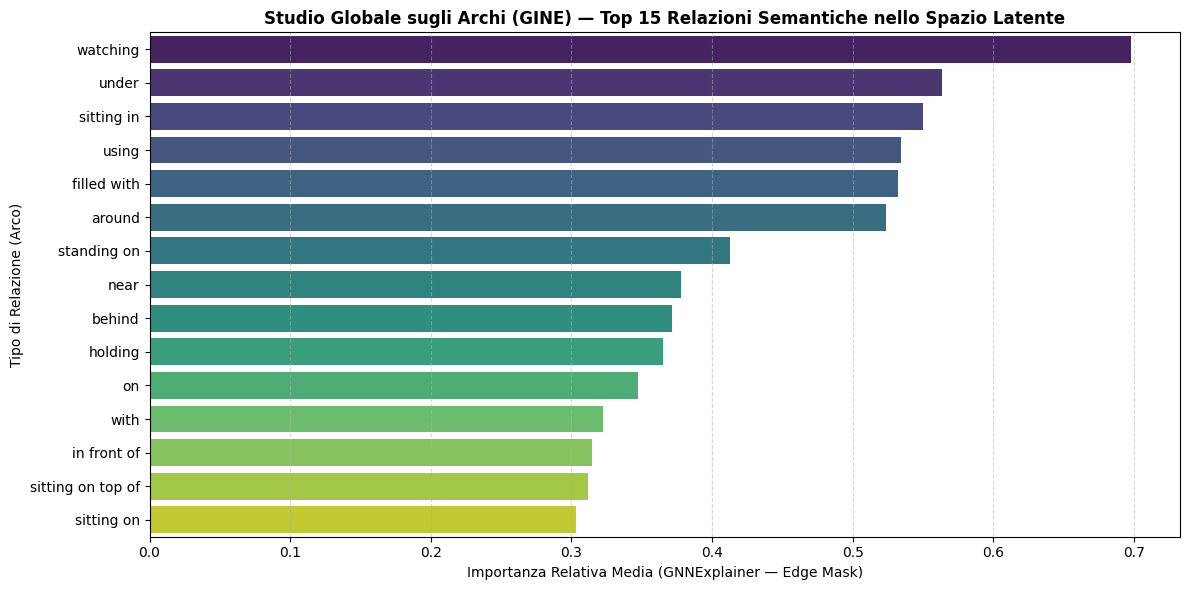

In [9]:
df_edges_gine = analyze_global_edge_importance_with_explainer(
    dataset_gine=val_dataset_gine,
    model_gine=gine_model,
    rel_vocab_gine=rel_vocab_gine,
    device=device,
    num_samples=50,
)
print(df_edges_gine.head(15))
plot_global_edge_study(df_edges_gine, topk=15, model_name="GINE")

## Studio Globale degli Archi — GCN (GNNExplainer)

Analisi archi (GCN — GNNExplainer) su 50 campioni...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


             Relazione  Importanza Media  Conteggio
0        tree → banana          0.893924          2
1      bottle → toilet          0.880173          2
2   television → shelf          0.876017          1
3     shirt → suitcase          0.868735          1
4          bed → sheet          0.865094          1
5           hat → pole          0.862362          2
6       kettle → sheet          0.859348          2
7        fish → bottle          0.857818          2
8          coat → eyes          0.856516          2
9   motorcycle → tiger          0.854743          1
10      person → grass          0.852308          1
11        bench → door          0.851538          2
12        rock → cliff          0.850963          2
13      tree → numbers          0.843545          2
14     building → dome          0.842942          1


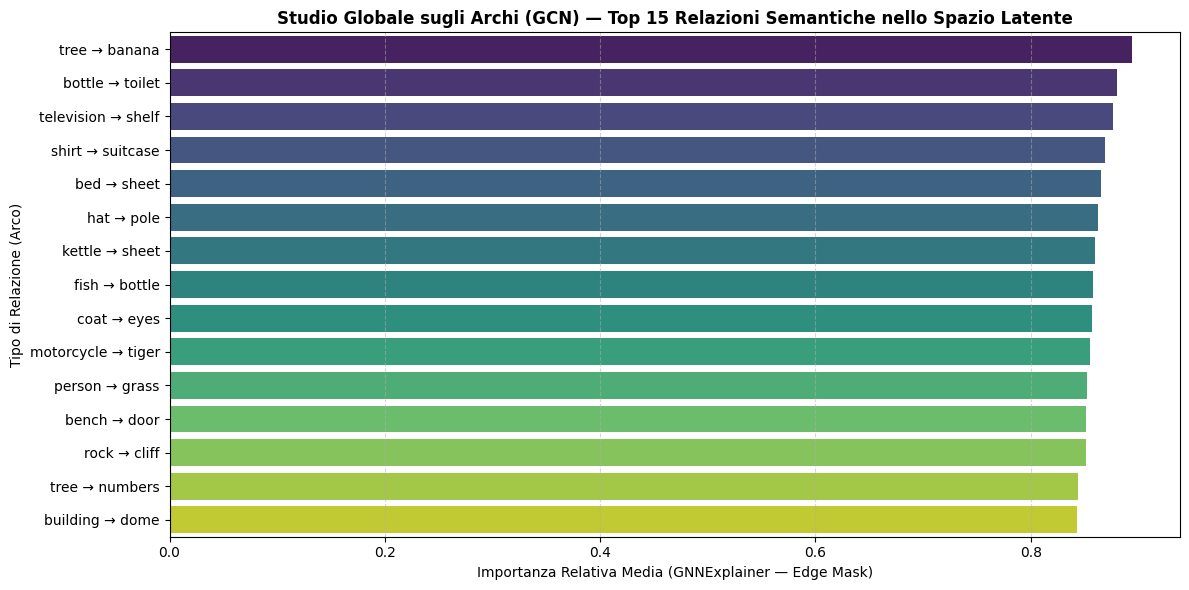

In [10]:
df_edges_gcn = analyze_global_edge_importance_gcn(
    dataset_gcn=val_dataset_gcn,
    model_gcn=gcn_model,
    node_vocab_gcn=node_vocab_gcn,
    device=device,
    num_samples=50,
)
print(df_edges_gcn.head(15))
plot_global_edge_study(df_edges_gcn, topk=15, model_name="GCN")